# REC 图（MedVAE 骨干）：原图 vs 各方法重构

对标 `reference/paper/doc/Image/RECmnist.pdf`（MLP 侧），在 **MedVAE 骨干**上重画。
**只加载已训好的 checkpoint 做推理，不训练。**

口径（与 `docs/E5-results_medvae-FID-MSE汇总.md` 的论文主表一致）：

| 方法 | run_tag | 备注 |
|---|---|---|
| VAE / IWAE | `vae_kl_1e-05` / `iwae_kl_1e-05` | 主表锚 1e-05 档 |
| SDVAE | `dq_1e-05_klt_1e-08`（cifar100 老 tag `sd_klt_1e8`） | 本仓库方法 |
| PM | `pm` | |
| P-VAE | `pvae_final_klw*_pi*` | 逐数据集最优配置 |
| ~~NCP~~ | `ncp` + `bc_logits.pth` | **默认不画**——参考图 RECmnist 就是这 5 个方法，无 NCP。`INCLUDE_NCP=True` 可加回（走阶段二 Langevin 重构，noise_s50_lr1e-4） |

- 权重优先取 **`_epoch10.pth`** 而非 `_best.pth`：`run_training` 训完是直接 eval 内存里的最终模型，
  主表 FID/MSE 对应的就是 epoch10 权重。
- **挑图用 MSE**：FID 定义在图像集合上，因此单张图无法测量 FID，所以逐图分析改用 MSE。
- 流程：**Part A** 扫描 checkpoint（先跑这个，确认权重都在）→ **Part B** 算逐图 MSE、挑图、出图。

## lib + 配置

In [26]:
# ==========================================
# 1. 依赖 + 配置（本 notebook 不训练，不需要 LPIPS/判别器）
# ==========================================
import os
import io
import math
import glob
import json
import numpy as np
from PIL import Image
import functools

import datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from einops import rearrange
from tqdm import tqdm
import matplotlib.pyplot as plt

# ========== 唯一需要改的开关 ==========
TARGET_DATASET  = "cifar100"   # mnist / fashion-mnist / cifar10 / cifar100 / tiny-image-net
INCLUDE_NCP     = False        # False=5 行, 与参考图 RECmnist 一致(Sample/VAE/IWAE/PM/P-VAE/SDVAE)
                               # True=6 行, 加 NCP(与 medvae 主表 6 方法一致, 要多跑 Langevin)
NUM_COLS        = 10           # 图的列数（RECmnist 是 10）
MAX_EVAL_IMAGES = None         # None=全测试集；想快可设 2000
CUDA_NUM        = 0
SEED            = 42
# 挑图准则：
#   "gap_covered"  —— 每列至少有一个基线明显崩(视觉冲击大), 且每个基线都被展示到崩一次(默认)
#   "beats_best"   —— SDVAE 连最强对手都赢(旧准则, 整行小幅落后, 差异不明显)
PICK_MODE       = "gap_covered"
# =====================================

CKPT_ROOT = "/home/yzm/ipy/checkpoints"
OUT_DIR   = "/home/yzm/ipy/recfig_out"
os.makedirs(OUT_DIR, exist_ok=True)

# 各数据集的固定项（与 z_med_*/ 各 notebook 的 Config 一致）
DATASET_CFG = {
    "mnist":          dict(dir="/home/yzm/data_mnist",          key="image", size=28, ch=1),
    "fashion-mnist":  dict(dir="/home/yzm/data_fashion_mnist",  key="image", size=28, ch=1),
    "cifar10":        dict(dir="/home/yzm/data_cifar10",        key="img",   size=32, ch=3),
    "cifar100":       dict(dir="/home/yzm/data_cifar100",       key="img",   size=32, ch=3),
    "tiny-image-net": dict(dir="/home/yzm/data_tiny_image_net", key="image", size=64, ch=3),
}
assert TARGET_DATASET in DATASET_CFG, f"未知数据集: {TARGET_DATASET}"
_dc = DATASET_CFG[TARGET_DATASET]


class Config:
    DATASET_NAME = TARGET_DATASET
    DATASET_DIR = _dc["dir"]
    TRAIN_DATASET_DIR = os.path.join(_dc["dir"], "train")
    TEST_DATASET_DIR = os.path.join(_dc["dir"], "test")
    IMAGE_KEY = _dc["key"]
    IMG_SIZE = _dc["size"]
    IMG_CHANNELS = _dc["ch"]
    BATCH_SIZE = 64
    NUM_WORKERS = 4
    VAL_SPLIT_RATIO = 0.1
    SPLIT_SEED = 42
    CUDA_NUM = CUDA_NUM


config = Config()
device = torch.device(f"cuda:{config.CUDA_NUM}" if torch.cuda.is_available() else "cpu")

print(f"Device      : {device}")
print(f"Dataset     : {config.DATASET_NAME} ({config.IMG_SIZE}x{config.IMG_SIZE}x{config.IMG_CHANNELS})")
print(f"Dataset dir : {config.DATASET_DIR}")
print(f"Ckpt root   : {CKPT_ROOT}")
print(f"Out dir     : {OUT_DIR}")
print(f"含 NCP 行   : {INCLUDE_NCP}")

Device      : cuda:0
Dataset     : cifar100 (32x32x3)
Dataset dir : /home/yzm/data_cifar100
Ckpt root   : /home/yzm/ipy/checkpoints
Out dir     : /home/yzm/ipy/recfig_out
含 NCP 行   : False


## MedVAE 骨干（与训练时逐字一致，勿改）

In [27]:
# ==========================================
# MedVAE 核心组件: Encoder & Decoder
# ==========================================

def nonlinearity(x):
    """Swish激活函数"""
    return x * torch.sigmoid(x)

def Normalize(in_channels, num_groups=32):
    return nn.GroupNorm(num_groups=num_groups, num_channels=in_channels, eps=1e-6, affine=True)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x)
        q, k, v = rearrange(qkv, "b (qkv heads c) h w -> qkv b heads c (h w)", heads=self.heads, qkv=3)
        k = k.softmax(dim=-1)
        context = torch.einsum("bhdn,bhen->bhde", k, v)
        out = torch.einsum("bhde,bhdn->bhen", context, q)
        out = rearrange(out, "b heads c (h w) -> b (heads c) h w", heads=self.heads, h=h, w=w)
        return self.to_out(out)

class LinAttnBlock(LinearAttention):
    def __init__(self, in_channels):
        super().__init__(dim=in_channels, heads=1, dim_head=in_channels)

class AttnBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.norm = Normalize(in_channels)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        h_ = self.norm(x)
        q, k, v = self.q(h_), self.k(h_), self.v(h_)
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).permute(0, 2, 1)
        k = k.reshape(b, c, h * w)
        w_ = torch.bmm(q, k) * (int(c) ** (-0.5))
        w_ = F.softmax(w_, dim=2)
        v = v.reshape(b, c, h * w)
        w_ = w_.permute(0, 2, 1)
        h_ = torch.bmm(v, w_).reshape(b, c, h, w)
        return x + self.proj_out(h_)

def make_attn(in_channels, attn_type="vanilla"):
    if attn_type == "vanilla":
        return AttnBlock(in_channels)
    elif attn_type == "none":
        return nn.Identity(in_channels)
    else:
        return LinAttnBlock(in_channels)

class Upsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x

class Downsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)

    def forward(self, x):
        if self.with_conv:
            x = F.pad(x, (0, 1, 0, 1), mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels=None, conv_shortcut=False, dropout, temb_channels=512):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut

        self.norm1 = Normalize(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        if temb_channels > 0:
            self.temb_proj = nn.Linear(temb_channels, out_channels)
        self.norm2 = Normalize(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x, temb):
        h = nonlinearity(self.norm1(x))
        h = self.conv1(h)
        if temb is not None:
            h = h + self.temb_proj(nonlinearity(temb))[:, :, None, None]
        h = nonlinearity(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        if self.in_channels != self.out_channels:
            x = self.conv_shortcut(x) if self.use_conv_shortcut else self.nin_shortcut(x)
        return x + h

In [28]:
# ==========================================
# Encoder 和 Decoder 类
# ==========================================

class Encoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 double_z=True, use_linear_attn=False, attn_type="vanilla", **ignore_kwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels

        # downsampling
        self.conv_in = nn.Conv2d(in_channels, self.ch, kernel_size=3, stride=1, padding=1)
        curr_res = resolution
        in_ch_mult = (1,) + tuple(ch_mult)
        self.down = nn.ModuleList()
        
        for i_level in range(self.num_resolutions):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_in = ch * in_ch_mult[i_level]
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            down = nn.Module()
            down.block = block
            down.attn = attn
            if i_level != self.num_resolutions - 1:
                down.downsample = Downsample(block_in, resamp_with_conv)
                curr_res = curr_res // 2
            self.down.append(down)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, 2 * z_channels if double_z else z_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        temb = None
        hs = [self.conv_in(x)]
        for i_level in range(self.num_resolutions):
            for i_block in range(self.num_res_blocks):
                h = self.down[i_level].block[i_block](hs[-1], temb)
                if len(self.down[i_level].attn) > 0:
                    h = self.down[i_level].attn[i_block](h)
                hs.append(h)
            if i_level != self.num_resolutions - 1:
                hs.append(self.down[i_level].downsample(hs[-1]))
        h = hs[-1]
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


class Decoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 give_pre_end=False, tanh_out=False, use_linear_attn=False, attn_type="vanilla", **ignorekwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels
        self.give_pre_end = give_pre_end
        self.tanh_out = tanh_out

        block_in = ch * ch_mult[self.num_resolutions - 1]
        curr_res = resolution // 2 ** (self.num_resolutions - 1)

        # z to block_in
        self.conv_in = nn.Conv2d(z_channels, block_in, kernel_size=3, stride=1, padding=1)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # upsampling
        self.up = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks + 1):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            up = nn.Module()
            up.block = block
            up.attn = attn
            if i_level != 0:
                up.upsample = Upsample(block_in, resamp_with_conv)
                curr_res = curr_res * 2
            self.up.insert(0, up)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, out_ch, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        temb = None
        h = self.conv_in(z)
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        for i_level in reversed(range(self.num_resolutions)):
            for i_block in range(self.num_res_blocks + 1):
                h = self.up[i_level].block[i_block](h, temb)
                if len(self.up[i_level].attn) > 0:
                    h = self.up[i_level].attn[i_block](h)
            if i_level != 0:
                h = self.up[i_level].upsample(h)
        if self.give_pre_end:
            return h
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        if self.tanh_out:
            h = torch.tanh(h)
        return h

In [29]:
# ==========================================
# DiagonalGaussianDistribution (潜在空间分布)
# ==========================================

class DiagonalGaussianDistribution:
    def __init__(self, parameters, deterministic=False):
        self.parameters = parameters
        self.mean, self.logvar = torch.chunk(parameters, 2, dim=1)
        self.logvar = torch.clamp(self.logvar, -30.0, 20.0)
        self.deterministic = deterministic
        self.std = torch.exp(0.5 * self.logvar)
        self.var = torch.exp(self.logvar)
        if self.deterministic:
            self.var = self.std = torch.zeros_like(self.mean).to(device=self.parameters.device)

    def sample(self):
        x = self.mean + self.std * torch.randn(self.mean.shape).to(device=self.parameters.device)
        return x

    def kl(self, other=None):
        if self.deterministic:
            return torch.Tensor([0.0])
        if other is None:
            return 0.5 * torch.sum(torch.pow(self.mean, 2) + self.var - 1.0 - self.logvar, dim=[1, 2, 3])
        else:
            return 0.5 * torch.sum(
                torch.pow(self.mean - other.mean, 2) / other.var + self.var / other.var - 1.0 - self.logvar + other.logvar,
                dim=[1, 2, 3],
            )

    def nll(self, sample, dims=[1, 2, 3]):
        if self.deterministic:
            return torch.Tensor([0.0])
        logtwopi = np.log(2.0 * np.pi)
        return 0.5 * torch.sum(logtwopi + self.logvar + torch.pow(sample - self.mean, 2) / self.var, dim=dims)

    def mode(self):
        return self.mean

## 模型类：AutoencoderKL（vae/iwae/sd/pm/ncp 共用）

In [30]:
# ==========================================
# AutoencoderKL 模型 (更适合 CIFAR10 重建的配置)
# ==========================================

class AutoencoderKL(nn.Module):
    """
    2D VAE 模型
    - 4x 空间压缩
    - RGB 三通道输入
    - 更大的潜在容量用于提升 CIFAR10 重建质量
    """
    def __init__(self, ddconfig, embed_dim, ckpt_path=None, ignore_keys=[], apply_channel_ds=False):
        super().__init__()
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)

        assert ddconfig["double_z"]
        self.quant_conv = nn.Conv2d(2 * ddconfig["z_channels"], 2 * embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)
        self.embed_dim = embed_dim
        self.latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
        self.latent_resolution = ddconfig["resolution"] // self.latent_downsample_factor

        self.apply_channel_ds = apply_channel_ds
        if self.apply_channel_ds:
            self.channel_ds = nn.Sequential(
                nn.Conv2d(self.embed_dim, 64, 1),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding="same"),
                nn.ReLU(),
                nn.Conv2d(64, self.embed_dim, 1),
            )
            self.channel_proj = nn.Conv2d(self.embed_dim, self.embed_dim, 1)

        if ckpt_path is not None:
            self.init_from_ckpt(ckpt_path, ignore_keys=ignore_keys)

    def init_from_ckpt(self, path, ignore_keys=[]):
        sd = torch.load(path, map_location="cpu")
        if "state_dict" in sd:
            sd = sd["state_dict"]
        keys = list(sd.keys())
        for k in keys:
            for ik in ignore_keys:
                if k.startswith(ik):
                    print(f"Deleting key {k} from state_dict.")
                    del sd[k]
        self.load_state_dict(sd, strict=False)
        print(f"Restored from {path}")

    def encode(self, x):
        """编码: 图像 -> 潜在分布"""
        h = self.encoder(x)
        moments = self.quant_conv(h)
        posterior = DiagonalGaussianDistribution(moments)
        return posterior

    def decode(self, z):
        """解码: 潜在向量 -> 图像"""
        z = self.post_quant_conv(z)
        dec = self.decoder(z)
        return dec

    def forward(self, input, sample_posterior=True):
        """前向传播"""
        posterior = self.encode(input)
        if sample_posterior:
            z = posterior.sample()
        else:
            z = posterior.mode()

        if self.apply_channel_ds:
            z = self.channel_proj(self.channel_ds(z) + z)

        dec = self.decode(z)
        return dec, posterior, z

    def get_last_layer(self):
        """获取decoder最后一层权重 (用于自适应权重计算)"""
        return self.decoder.conv_out.weight

## 模型类：AutoencoderPVAE（P-VAE 专用，double_z=False）

In [31]:
# ==========================================
# Poisson 后验 (替代 DiagonalGaussianDistribution) + Poisson KL
# 来自 pvae copy 1-5.ipynb 的 VAE.reparameterize / poisson_kl_logrates，
# 从 [B, latent_dim] 向量潜在空间适配到 medvae 的 [B, C, h, w] 空间潜在张量
# ==========================================

def poisson_kl_logrates(log_rate_q, log_rate_prior, eps=1e-6, clamp_max=5.0):
    """KL(Poisson(r_q) || Poisson(r)) = r - r_q + r_q*(log r_q - log r)，逐元素"""
    lrq = log_rate_q.clamp(max=clamp_max)
    lrp = log_rate_prior.clamp(max=clamp_max)
    r_q = torch.exp(lrq) + eps
    r = torch.exp(lrp) + eps
    kl = r - r_q + r_q * (torch.log(r_q) - torch.log(r))
    return kl


class PoissonPosterior:
    """
    PVAE 的潜在后验: log_rate_q = du + prior (可训练)，z ~ Poisson(exp(log_rate_q))。

    采样用 pvae notebook 的重参数化方案: 指数分布到达时间 cumsum 后
    soft indicator (sigmoid((1-times)/t)) 求和得到可微的 soft 计数；
    hard 模式 (eval) 用严格 indicator(times < 1) 得到整数计数。
    n_trials 按 ceil(max(rate,1)*5) 自适应，n_trials_min 兜底。
    """
    def __init__(self, du, prior_log_rate, t=1.0, n_trials_min=10, clamp_max=5.0):
        self.du = du                                   # [B, C, h, w]
        self.prior_log_rate = prior_log_rate           # [1, C, h, w] (broadcast)
        self.t = float(t)
        self.n_trials_min = int(n_trials_min)
        self.log_rate_q = (du + prior_log_rate).clamp(max=clamp_max)
        self.rate = torch.exp(self.log_rate_q) + 1e-8

    def sample(self, hard=None):
        # 与 pvae notebook 的 hard=None 启发式一致: 训练 (有梯度) 用 soft，eval 用 hard
        if hard is None:
            hard = not torch.is_grad_enabled()

        rate_max = self.rate.max().item()
        n_trials = max(int(math.ceil(max(rate_max, 1.0) * 5.0)), self.n_trials_min)

        # [n_trials, B, C, h, w] 的指数到达间隔，rsample 保持重参数化梯度
        expo = torch.distributions.Exponential(
            self.rate.unsqueeze(0).expand(n_trials, -1, -1, -1, -1)
        )
        x = expo.rsample()
        times = torch.cumsum(x, dim=0)

        if hard or self.t == 0.0:
            indicator = (times < 1.0).float()
        else:
            indicator = torch.sigmoid((1.0 - times) / (self.t + 1e-12))

        return indicator.sum(dim=0)                    # [B, C, h, w] 计数

    def kl_per_dim(self):
        """逐元素 Poisson KL [B, C, h, w]（纯净族按 pvae notebook 口径取 .mean()）"""
        return poisson_kl_logrates(self.log_rate_q, self.prior_log_rate)

    def kl(self):
        """medvae 口径: 潜在维度求和 -> [B]（criterion 里再 .mean()，与高斯 KL 同构）"""
        return self.kl_per_dim().sum(dim=[1, 2, 3])

    def mode(self):
        """Poisson 众数 floor(rate)，仅作接口补全；评估走 hard sample 与 pvae notebook 一致"""
        return torch.floor(self.rate)

In [32]:
# ==========================================
# AutoencoderPVAE 模型: medvae 的 Encoder/Decoder + PVAE 的 Poisson 潜在头
#   - double_z=False: encoder 输出单头 du (log-rate 增量)，不是 mu/logvar
#   - prior: 可训练 log-rate (对应 pvae notebook 的 nn.Parameter([1, latent_dim])，
#     这里逐潜在元素 [1, embed_dim, h, w])
#   - t: 采样温度，由训练循环按 epoch 退火 (1.0 -> 0.05)
# ==========================================

class AutoencoderPVAE(nn.Module):
    """
    2D PVAE 模型
    - 4x 空间压缩 (与 medvae AutoencoderKL 相同的 Encoder/Decoder)
    - 潜在空间为 Poisson 计数张量 [B, embed_dim, h, w]
    """
    def __init__(self, ddconfig, embed_dim, prior_init=0.0, n_trials_min=10):
        super().__init__()
        assert not ddconfig["double_z"], "PVAE 单头 du 输出要求 double_z=False"
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)

        self.quant_conv = nn.Conv2d(ddconfig["z_channels"], embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)
        self.embed_dim = embed_dim
        self.latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
        self.latent_resolution = ddconfig["resolution"] // self.latent_downsample_factor

        # 可训练 prior log-rate (pvae notebook: prior_init=0.0 即初始速率 1)
        self.prior = nn.Parameter(
            torch.ones(1, embed_dim, self.latent_resolution, self.latent_resolution)
            * float(prior_init)
        )
        # 采样温度与最小 trials 数，训练循环按 epoch 设置/退火
        self.t = 1.0
        self.n_trials_min = int(n_trials_min)

    def encode(self, x):
        """编码: 图像 -> Poisson 潜在后验"""
        h = self.encoder(x)
        du = self.quant_conv(h)
        return PoissonPosterior(du, self.prior, t=self.t, n_trials_min=self.n_trials_min)

    def decode(self, z):
        """解码: 潜在计数 -> 图像"""
        z = self.post_quant_conv(z)
        dec = self.decoder(z)
        return dec

    def forward(self, input, sample_posterior=True):
        """前向传播 (与 AutoencoderKL 同签名，训练/评估循环可原样复用)"""
        posterior = self.encode(input)
        if sample_posterior:
            z = posterior.sample()
        else:
            z = posterior.mode()
        dec = self.decode(z)
        return dec, posterior, z

    def get_last_layer(self):
        """获取decoder最后一层权重 (用于自适应权重计算)"""
        return self.decoder.conv_out.weight

## NCP 阶段二/三：分类器 + Langevin

In [33]:
# ==========================================
# NCP 阶段二: 噪声对比二分类器 (来自 ncp_beta_vae copy 1-5)
# 正样本: z ~ q(z|x) 聚合后验 (整个训练集采集, 展平缓存到 CPU)
# 负样本: z ~ N(0, I) 先验
# 分类器 logits ≈ log r(z) = log(q(z)/p(z))  (密度比)
# ==========================================

class BinaryClassifierLogits(nn.Module):
    """
    ncp notebook 的 5 层 MLP 结构 (输出 logits, 末端无 sigmoid)。
    原版输入维度 5~40、隐层 (40,30,20,10)；medvae 潜在空间展平后为
    C*h*w (392~2048) 维，隐层等比放大 10 倍为 (400,300,200,100)。
    """
    def __init__(self, latent_dim):
        super().__init__()
        self.layer1 = nn.Linear(latent_dim, 400)
        self.layer2 = nn.Linear(400, 300)
        self.layer3 = nn.Linear(300, 200)
        self.layer4 = nn.Linear(200, 100)
        self.layer5 = nn.Linear(100, 1)   # logits

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = F.relu(self.layer4(x))
        return self.layer5(x)             # [B, 1]

In [34]:
# ==========================================
# NCP 阶段三: Langevin (SGLD) 迭代 + 评估
# 能量 E(z) = -logits(z) - log N(z; 0, I)
# 更新式 (ncp notebook 原版): z <- z - 0.5*eps*grad E + sqrt(eps)*noise
# ==========================================

NCP_BC_EPOCHS = 50            # 分类器训练 epoch (ncp notebook 原值)
NCP_N_STEPS = 50              # Langevin 步数 (2026-07-06 调参定稿, 原 200)
NCP_STEP_SIZE = 1e-4         # 步长 (2026-07-06 调参定稿 noise_s50_lr1e-4, 原 3e-4/5e-4)
NCP_CLAMP = 10.0              # 安全裁剪
NCP_ADD_NOISE = True          # Langevin 本质需要噪声
NCP_USE_MU = True             # 重建时 z 初始化用 mu (可改为后验采样)


def langevin_refine(bc_model, z0, n_steps=NCP_N_STEPS, step_size=NCP_STEP_SIZE,
                    clamp_val=NCP_CLAMP, add_noise=NCP_ADD_NOISE):
    """对 z0 ([B,C,h,w]) 在能量先验上做 Langevin 迭代，返回同形状的精修 z"""
    orig_shape = z0.shape
    B = z0.size(0)
    log_2pi = math.log(2 * math.pi)
    z = z0.reshape(B, -1).detach().clone().requires_grad_(True)

    for _ in range(n_steps):
        logits = bc_model(z).view(B)                    # logits ≈ log r(z)
        log_pz = -0.5 * (z ** 2 + log_2pi).sum(dim=1)   # log N(z; 0, I)
        energy = (-logits - log_pz).mean()
        grads = torch.autograd.grad(energy, z)[0]
        with torch.no_grad():
            z_new = z - 0.5 * step_size * grads
            if add_noise:
                z_new = z_new + torch.randn_like(z_new) * (step_size ** 0.5)
            z_new = torch.clamp(z_new, -clamp_val, clamp_val)
        z = z_new.detach().requires_grad_(True)

    return z.detach().reshape(orig_shape)

## ddconfig（小骨干，全方法/数据集一致）

In [35]:
# ==========================================
# 骨干 ddconfig：ch=32 / ch_mult=[1,2] / z_channels=4 / embed_dim=4
# P-VAE 只差 double_z=False（单头 du 输出）
# ==========================================

def make_ddconfig(double_z):
    return {
        "double_z": double_z,
        "z_channels": 4,
        "resolution": config.IMG_SIZE,
        "in_channels": config.IMG_CHANNELS,
        "out_ch": config.IMG_CHANNELS,
        "ch": 32,
        "ch_mult": [1, 2],
        "num_res_blocks": 2,
        "attn_resolutions": [config.IMG_SIZE // 2],
        "dropout": 0.0,
    }


embed_dim = 4
latent_resolution = config.IMG_SIZE // 2
print(f"骨干: ch=32, ch_mult=[1,2], z_channels=4, embed_dim={embed_dim}, 潜在 {latent_resolution}x{latent_resolution}")

骨干: ch=32, ch_mult=[1,2], z_channels=4, embed_dim=4, 潜在 16x16


## data（test split）

In [36]:
# ==========================================
# cifar100 Hugging Face 数据集 (VAE训练用，归一化到[-1,1])
# ==========================================
# 不同数据集存盘格式不一（cifar 系列 image 列直接是 PIL；mnist/fashion/tiny
# 可能是未解码的 {"bytes":...} 字典或 object 数组）。_DIAG_SEEN 保证每个
# split 只在第一张图打印一次真实类型，出问题时一眼看清是哪种形态。
_DIAG_SEEN = set()


class HFImageDataset(Dataset):
    """
    Hugging Face cifar100 数据集封装
    输出图像归一化到 [-1, 1] 范围
    """
    def __init__(self, split='train', augment=False):
        split_to_path = {
            'train': config.TRAIN_DATASET_DIR,
            'test': config.TEST_DATASET_DIR,
        }
        if split not in split_to_path:
            raise ValueError(f"Unsupported split: {split}")

        self.split = split
        self.dataset_path = split_to_path[split]
        self.image_key = config.IMAGE_KEY
        self.dataset = datasets.load_from_disk(self.dataset_path)
        transform_ops = [
            transforms.Resize(config.IMG_SIZE),
            transforms.CenterCrop(config.IMG_SIZE),
        ]
        if augment:
            transform_ops.append(transforms.RandomHorizontalFlip())
        transform_ops.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * config.IMG_CHANNELS, [0.5] * config.IMG_CHANNELS),
        ])
        self.transform = transforms.Compose(transform_ops)

        print(f"[{self.split}] 数据集路径: {self.dataset_path}")
        print(f"[{self.split}] 数据集大小: {len(self.dataset)}")
        print(f"[{self.split}] 数据集列: {self.dataset.column_names}")

    def __len__(self):
        return len(self.dataset)

    def _to_pil(self, img):
        """把 HF 一行的 image 字段统一转成 PIL Image，兼容三种存盘形态。"""
        if isinstance(img, Image.Image):                 # cifar 系列：已是 PIL
            return img
        if isinstance(img, dict):                        # 未解码的 HF Image feature
            if img.get("bytes") is not None:
                return Image.open(io.BytesIO(img["bytes"]))
            if img.get("path"):
                return Image.open(img["path"])
            raise TypeError(f"无法解码 image 字典，keys={list(img)}")
        arr = np.asarray(img)
        if arr.dtype == object:                          # ragged / 逐元素是对象 -> 先摊平成规整数值
            arr = np.array(arr.tolist())
        if arr.dtype != np.uint8:                        # 浮点/[0,1] 或 [0,255] 都归一到 uint8
            arr = (arr * 255).round().astype(np.uint8) if arr.max() <= 1.0 else arr.astype(np.uint8)
        return Image.fromarray(arr)

    def __getitem__(self, idx):
        img = self.dataset[idx][self.image_key]
        if self.split not in _DIAG_SEEN:                 # 每 split 首张打印真实类型，便于排错
            _DIAG_SEEN.add(self.split)
            extra = f" dtype={np.asarray(img).dtype} shape={np.asarray(img).shape}" \
                if not isinstance(img, (Image.Image, dict)) else ""
            print(f"[诊断 {config.DATASET_NAME}/{self.split}] image_key='{self.image_key}' "
                  f"原始类型={type(img).__name__}{extra}")
        img = self._to_pil(img)
        img = img.convert("RGB" if config.IMG_CHANNELS == 3 else "L")
        return self.transform(img)

In [37]:
# ==========================================
# 测试集 loader（shuffle=False，索引稳定可复现）
# ==========================================
test_dataset = HFImageDataset(split="test", augment=False)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    drop_last=False,
    pin_memory=True,
)
print(f"测试集大小: {len(test_dataset)}  batch 数: {len(test_loader)}")

[test] 数据集路径: /home/yzm/data_cifar100/test
[test] 数据集大小: 10000
[test] 数据集列: ['img', 'fine_label', 'coarse_label']
测试集大小: 10000  batch 数: 157


## Part A：扫描 checkpoint

**先只跑到这里**，确认权重都还在服务器上、tag 对得上，再往下跑 Part B。
下面会先列出实际存在的 run 目录和 tag（万一 tag 名和预期不符，看这里就知道要改什么）。

In [38]:
# ==========================================
# 各方法的 run_tag 口径（来自 docs/E5-results_medvae-FID-MSE汇总.md 论文主表 v3）
# ==========================================

# P-VAE 逐数据集最优配置（2026-07-06 拍板，见 docs/E5-results_medvae-FID-MSE汇总.md「拍板结果」）
# tag 按优先级两候选：
#   pvae_final_klw*_pi*  —— ×5 终跑（rerun_final_s*.sh），跑完才有，届时自动优先命中
#   pvae_klw*_pi*        —— 07-05 调参扫描（n=1），v3 主表 P-VAE 行的实际来源
# 故意不把裸 tag "pvae" 列为候选：那是调参前的 klw1e-5_pi0 老配置（cifar100 FID 13.98
# vs 调参后 12.34），与 v3 主表不是同一批；留着会在 final 缺席时静默退到它，把 P-VAE 行画错。
PVAE_TAG = {
    "mnist":          ["pvae_final_klw1e-08_pi0", "pvae_klw1e-08_pi0"],
    "fashion-mnist":  ["pvae_final_klw1e-08_pi2", "pvae_klw1e-08_pi2"],
    "cifar10":        ["pvae_final_klw1e-10_pi2", "pvae_klw1e-10_pi2"],
    "cifar100":       ["pvae_final_klw1e-08_pi2", "pvae_klw1e-08_pi2"],
    "tiny-image-net": ["pvae_final_klw1e-10_pi2", "pvae_klw1e-10_pi2"],
}

# NCP 阶段一 base checkpoint（仅 INCLUDE_NCP=True 时用；与各 ncp notebook 的 run cell 一致）
NCP_BASE_CKPT = {
    "mnist":          f"{CKPT_ROOT}/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth",
    "fashion-mnist":  f"{CKPT_ROOT}/medvae-re-fashion-mnist-06-24_00-50/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth",
    "cifar10":        f"{CKPT_ROOT}/medvae-re-cifar10-06-22_14-53/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth",
    "cifar100":       f"{CKPT_ROOT}/medvae-re-ncp-cifar100-06-26_20-24/ncp/medvae_ncp_epoch10.pth",
    "tiny-image-net": f"{CKPT_ROOT}/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth",
}

def build_specs(ds, include_ncp=False):
    """行顺序与参考图 RECmnist 一致：Sample / VAE / IWAE / PM / P-VAE / SDVAE。

    tags 按优先级给候选（cifar100 的 sd/vae/iwae 有 06-19 老格式 tag，故有第二候选）。
    """
    specs = [
        dict(name="VAE",   kind="kl",   family="e5",   tags=["vae_kl_1e-05", "vae"]),
        dict(name="IWAE",  kind="kl",   family="e5",   tags=["iwae_kl_1e-05", "iwae"]),
        dict(name="PM",    kind="kl",   family="pm",   tags=["pm"]),
        dict(name="P-VAE", kind="pvae", family="pvae", tags=PVAE_TAG[ds]),
    ]
    if include_ncp:
        specs.append(dict(name="NCP", kind="ncp", family="ncp", tags=["ncp"]))
    specs.append(dict(name="SDVAE", kind="kl", family="e5",
                      tags=["dq_1e-05_klt_1e-08", "sd_klt_1e8"]))
    return specs


def _run_glob(family, ds):
    prefix = "medvae-re" if family == "e5" else f"medvae-re-{family}"
    return f"{CKPT_ROOT}/{prefix}-{ds}-*"


def find_ckpt(family, ds, tags):
    """按 tag 优先级找权重；同 tag 命中多个 run 目录时取 mtime 最新。

    优先 _epoch10.pth 而非 _best.pth：run_training 训练完是直接 eval 内存里的
    最终模型，主表 FID/MSE 对应的就是 epoch10 权重。
    """
    for tag in tags:
        for fname in [f"medvae_{tag}_epoch10.pth", f"medvae_{tag}_best.pth"]:
            hits = glob.glob(f"{_run_glob(family, ds)}/{tag}/{fname}")
            if hits:
                hits.sort(key=os.path.getmtime, reverse=True)
                return hits[0], tag
    return None, None


def list_server_runs(ds):
    """打印服务器上实际存在的 run 目录与 tag（tag 对不上时照这个列表改 SPECS）"""
    print(f"### {ds}: 服务器上实际存在的 run 目录与 tag" + chr(10))
    found = False
    for fam in ["e5", "pm", "pvae", "ncp"]:
        for rd in sorted(glob.glob(_run_glob(fam, ds))):
            found = True
            subs = sorted(os.path.basename(x) for x in glob.glob(rd + "/*") if os.path.isdir(x))
            print(f"  [{fam:<4}] {os.path.basename(rd)}")
            print(f"         tags: {subs}")
    if not found:
        print(f"  (空) —— {CKPT_ROOT} 下没有 {ds} 的 run 目录，检查 CKPT_ROOT 是否正确")


SPECS = build_specs(TARGET_DATASET, INCLUDE_NCP)
list_server_runs(TARGET_DATASET)


### cifar100: 服务器上实际存在的 run 目录与 tag

  [e5  ] medvae-re-cifar100-06-19_15-30
         tags: ['iwae', 'sd_abl1_gan_off', 'sd_abl2_dq1e-6', 'sd_abl3_klt_off', 'sd_abl4_bck_v4', 'sd_klt_1e4', 'sd_klt_1e5', 'sd_klt_1e6', 'sd_klt_1e8', 'sd_klt_4e8', 'vae']
  [e5  ] medvae-re-cifar100-07-04_19-32
         tags: []
  [e5  ] medvae-re-cifar100-07-04_19-40
         tags: []
  [e5  ] medvae-re-cifar100-07-04_19-59
         tags: ['iwae_kl_1e-05', 'vae_kl_1e-05']
  [pm  ] medvae-re-pm-cifar100-06-27_15-57
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-06-27_16-20
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-07-04_19-06
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-07-04_19-33
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-07-04_19-40
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-07-04_19-56
         tags: ['pm']
  [pm  ] medvae-re-pm-cifar100-07-04_21-41
         tags: ['pm']
  [pvae] medvae-re-pvae-cifar100-06-25_12-12
         tags: ['pvae']
  [pvae] medvae-re-

In [39]:
# ==========================================
# 解析各方法权重，汇报状态
# ==========================================

def resolve_ckpts(specs, ds):
    """按 specs 找权重并打印状态表；返回 (resolved, missing)。

    resolved[name] 里带 ds：load_model 取 NCP 阶段一 base 要用，
    不能依赖全局 TARGET_DATASET（Part C 会把它切走）。
    """
    resolved = {}
    print(f"{'方法':<8}{'状态':<8}{'tag':<28}权重")
    print("-" * 110)
    for spec in specs:
        path, tag = find_ckpt(spec["family"], ds, spec["tags"])
        extra_ok = True
        note = ""
        if spec["kind"] == "ncp":
            # NCP 还需要阶段二分类器 bc_logits.pth + 阶段一 base 权重
            bc_hits = glob.glob(f"{_run_glob('ncp', ds)}/ncp/bc_logits.pth")
            base = NCP_BASE_CKPT[ds]
            path = max(bc_hits, key=os.path.getmtime) if bc_hits else None
            extra_ok = bool(bc_hits) and os.path.exists(base)
            note = ("缺 bc_logits.pth" if not bc_hits else
                    (f"缺阶段一 base: {base}" if not os.path.exists(base)
                     else f"base={os.path.basename(base)}"))
            tag = "ncp"

        ok = path is not None and extra_ok
        if ok and spec["tags"] and tag != spec["tags"][0]:
            # 命中的不是首选 tag：说明首选那批权重服务器上没有，退到了后备候选。
            # 不是错误（如 SDVAE 首选新格式 tag、实际用 06-19 老格式），但要看得见，
            # 免得像 P-VAE 那样静默退到不同批次的权重、跟主表对不上还不知道为什么。
            note = (note + "; " if note else "") + f"[备选] 首选 {spec['tags'][0]} 不存在"
        resolved[spec["name"]] = dict(spec, ds=ds, path=path, tag=tag, ok=ok)
        print(f"{spec['name']:<8}{('OK' if ok else '缺失'):<8}{str(tag):<28}{path if path else '(未找到)'}")
        if note:
            print(f"{'':<44}{note}")

    miss = [n for n, r in resolved.items() if not r["ok"]]
    print("-" * 110)
    if miss:
        print(f"[!] 缺失: {miss}")
        print("    -> 对照上面「实际存在的 tag」列表改 build_specs 的 tags，或换数据集。")
    else:
        print(f"[OK] {ds}: 全部方法权重就位。")
    return resolved, miss


RESOLVED, missing = resolve_ckpts(SPECS, TARGET_DATASET)


方法      状态      tag                         权重
--------------------------------------------------------------------------------------------------------------
VAE     OK      vae_kl_1e-05                /home/yzm/ipy/checkpoints/medvae-re-cifar100-07-04_19-59/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth
IWAE    OK      iwae_kl_1e-05               /home/yzm/ipy/checkpoints/medvae-re-cifar100-07-04_19-59/iwae_kl_1e-05/medvae_iwae_kl_1e-05_epoch10.pth
PM      OK      pm                          /home/yzm/ipy/checkpoints/medvae-re-pm-cifar100-07-04_21-41/pm/medvae_pm_epoch10.pth
P-VAE   OK      pvae_klw1e-08_pi2           /home/yzm/ipy/checkpoints/medvae-re-pvae-cifar100-07-05_19-58/pvae_klw1e-08_pi2/medvae_pvae_klw1e-08_pi2_epoch10.pth
                                            [备选] 首选 pvae_final_klw1e-08_pi2 不存在
SDVAE   OK      sd_klt_1e8                  /home/yzm/ipy/checkpoints/medvae-re-cifar100-06-19_15-30/sd_klt_1e8/medvae_sd_klt_1e8_epoch10.pth
                                    

## Part B：逐图 MSE → 挑图 → 出图

**FID 定义在图像集合上，因此单张图无法测量 FID，所以逐图分析改用 MSE。**

第一趟在全测试集上算每张图、每个方法的 MSE，顺带把全集均值与论文主表核对
（对得上就说明权重加载正确、口径没跑偏）。

In [40]:
# ==========================================
# 论文主表 MSE（x10^-3，docs/E5-results_medvae-FID-MSE汇总.md「终稿数据 v3」）
# 用于核对本 notebook 加载的权重是否与主表同一批
# ==========================================
# 每格 (mean, std)，n=5。std 必须带上：cifar100 IWAE 是 4.36±1.02，
# 单个 checkpoint 落在 3.8 完全正常，用固定 ±8% 容差会误判成「对不上」。
MAIN_TABLE_MSE = {
    "mnist":          {"SDVAE": (0.50, 0.01), "VAE": (0.68, 0.03), "IWAE": (0.71, 0.04),
                       "PM": (0.68, 0.04), "P-VAE": (1.46, 0.12), "NCP": (0.99, 0.01)},
    "fashion-mnist":  {"SDVAE": (1.92, 0.86), "VAE": (3.40, 0.40), "IWAE": (3.61, 0.28),
                       "PM": (3.03, 0.95), "P-VAE": (3.45, 0.31), "NCP": (3.70, 0.02)},
    "cifar10":        {"SDVAE": (2.88, 0.08), "VAE": (3.45, 0.12), "IWAE": (3.70, 0.19),
                       "PM": (3.36, 0.13), "P-VAE": (4.58, 0.25), "NCP": (3.04, 0.02)},
    "cifar100":       {"SDVAE": (2.98, 0.22), "VAE": (3.68, 0.21), "IWAE": (4.36, 1.02),
                       "PM": (3.87, 0.06), "P-VAE": (6.02, 0.93), "NCP": (3.45, 0.01)},
    "tiny-image-net": {"SDVAE": (8.64, 0.68), "VAE": (10.47, 0.55), "IWAE": (10.65, 0.64),
                       "PM": (10.14, 0.56), "P-VAE": (9.91, 0.54), "NCP": (9.31, 0.03)},
}


def load_model(res):
    """按方法种类构造模型并加载权重（NCP 的自编码器用阶段一 base 权重）"""
    if res["kind"] == "pvae":
        model = AutoencoderPVAE(make_ddconfig(False), embed_dim, prior_init=0.0, n_trials_min=10).to(device)
        ckpt_path = res["path"]
    elif res["kind"] == "ncp":
        model = AutoencoderKL(make_ddconfig(True), embed_dim).to(device)
        ckpt_path = NCP_BASE_CKPT[res["ds"]]
    else:
        model = AutoencoderKL(make_ddconfig(True), embed_dim).to(device)
        ckpt_path = res["path"]

    ckpt = torch.load(ckpt_path, map_location=device)
    state = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    model.load_state_dict(state)   # strict=True: 对不上直接报错，不静默降级
    model.eval()

    bc = None
    if res["kind"] == "ncp":
        bc = BinaryClassifierLogits(embed_dim * latent_resolution * latent_resolution).to(device)
        bc.load_state_dict(torch.load(res["path"], map_location=device))
        bc.eval()
    return model, bc


def recon_batch(res, model, bc, x):
    """重构一个 batch，口径与各方法自己的 eval 一致"""
    if res["kind"] == "ncp":
        # NCP: z0 取后验均值 (NCP_USE_MU=True) -> Langevin 精修 -> decode
        with torch.no_grad():
            z0 = model.encode(x).mean
        z = langevin_refine(bc, z0)          # 要对 z 求梯度，不能包在 no_grad 里
        with torch.no_grad():
            return model.decode(z)
    with torch.no_grad():
        # sample_posterior=True，与 evaluate_reconstruction_metrics 里的 model(images) 一致
        rec, _, _ = model(x)
        return rec


print("模型加载/重构口径已就绪")

模型加载/重构口径已就绪


In [41]:
# ==========================================
# 第一趟：全测试集逐图 MSE（每方法完整过一遍测试集）
# ==========================================

def compute_per_image_mse(resolved, loader, max_images=None):
    """每方法过一遍 loader，返回 {name: np.ndarray [N]} 的逐图 MSE"""
    pim = {}
    for name, res in resolved.items():
        model, bc = load_model(res)
        torch.manual_seed(SEED)          # 后验采样有随机性，固定种子保证可复现
        vals, seen = [], 0
        for x in tqdm(loader, desc=f"{name:<6}"):
            if max_images is not None and seen >= max_images:
                break
            x = x.to(device)
            rec = recon_batch(res, model, bc, x)
            vals.append(F.mse_loss(rec, x, reduction="none").mean(dim=(1, 2, 3)).detach().cpu())
            seen += x.size(0)
        pim[name] = torch.cat(vals).numpy()
        del model, bc
        torch.cuda.empty_cache()
    return pim


assert not missing, f"还有方法缺权重: {missing}，先解决 Part A"
per_image_mse = compute_per_image_mse(RESOLVED, test_loader, MAX_EVAL_IMAGES)
N_EVAL = len(next(iter(per_image_mse.values())))
print(chr(10) + f"逐图 MSE 完成：{N_EVAL} 张 x {len(per_image_mse)} 方法")


VAE   :   0%|          | 0/157 [00:00<?, ?it/s]

[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile


IWAE  :   0%|          | 0/157 [00:00<?, ?it/s]

[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile



IWAE  :   1%|          | 1/157 [00:00<00:36,  4.25it/s]

...

[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile


SDVAE :   0%|          | 0/157 [00:00<?, ?it/s]

[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile

[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile


SDVAE : 100%|██████████| 157/157 [00:03<00:00, 47.25it/s]


逐图 MSE 完成：10000 张 x 5 方法


In [42]:
# ==========================================
# 核对：全集 MSE 均值 vs 论文主表（对得上 = 权重/口径正确）
# ==========================================

def check_main_table(pim, ds):
    ref = MAIN_TABLE_MSE[ds]
    print(f"{ds}  MSE (x10^-3)" + chr(10))
    print(f"{'方法':<8}{'本次':>9}{'主表':>15}{'差':>8}{'偏离':>8}   判定")
    print("-" * 62)
    for name in pim:
        got = pim[name].mean() * 1e3
        if name not in ref:
            print(f"{name:<8}{got:>9.2f}{'-':>15}{'-':>8}{'-':>8}")
            continue
        exp, sd = ref[name]
        diff = got - exp
        # 容差取 2σ 与 8% 的较大者：σ 大的格子（cifar100 IWAE ±1.02）按 σ 判，
        # σ 极小的格子（PM ±0.06、NCP ±0.01）用 8% 兜底——单个 checkpoint 不可能落在
        # 5 次均值的 ±0.01 内，纯按 σ 判会全线误报。
        tol = max(2 * sd, 0.08 * exp)
        verdict = "一致" if abs(diff) <= tol else "[!] 对不上"
        nsig = abs(diff) / sd if sd else float("inf")
        cell = f"{exp:.2f}±{sd:.2f}"
        print(f"{name:<8}{got:>9.2f}{cell:>15}{diff:>+8.2f}{nsig:>7.1f}σ   {verdict}")
    print("-" * 62)
    print("注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；")
    print("    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。")
    print(chr(10) + f"本次 MSE 排序: {' < '.join(sorted(pim, key=lambda n: pim[n].mean()))}")
    print(f"主表 MSE 排序: {' < '.join(sorted(ref, key=lambda n: ref[n][0]))}   (含 NCP，本次未必画)")


check_main_table(per_image_mse, TARGET_DATASET)


cifar100  MSE (x10^-3)

方法             本次             主表       差      偏离   判定
--------------------------------------------------------------
VAE          4.03      3.68±0.21   +0.35    1.7σ   一致
IWAE         3.80      4.36±1.02   -0.56    0.5σ   一致
PM           3.84      3.87±0.06   -0.03    0.6σ   一致
P-VAE        6.01      6.02±0.93   -0.01    0.0σ   一致
SDVAE        3.15      2.98±0.22   +0.17    0.8σ   一致
--------------------------------------------------------------
注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；
    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。

本次 MSE 排序: SDVAE < IWAE < PM < VAE < P-VAE
主表 MSE 排序: SDVAE < NCP < VAE < PM < IWAE < P-VAE   (含 NCP，本次未必画)


### 挑图

老准则 `beats_best`：优势分 `adv = min(其他方法) - SDVAE`，挑 SDVAE **连最强对手都赢**的图。
问题是这挑出来的往往是「所有基线一起小幅落后」，落到小图上整行看着差不多，差异不明显。

新准则 `gap_covered`（默认，`PICK_MODE` 切换）：视觉冲击来自**最大差距**而非最小差距——
每张图只要**有一个基线明显崩**就有看点，不必所有基线都比 SDVAE 差一截。具体：

1. **候选**只保留 SDVAE 确实最好（`SDVAE ≤ 所有基线`）的图，保证图诚实、SDVAE 不会看着更差；
2. **覆盖**：每个基线各取「它相对 SDVAE 差距最大」的一张，保证**每个方法至少崩一次**（你要的）；
3. 余下列按**全场最大差距**补满，最后按差距降序排列，从最惊艳到最平。

In [43]:
# ==========================================
# 挑图：gap_covered(默认) / beats_best(旧)，PICK_MODE 切换
# ==========================================
TOP_POOL = NUM_COLS      # 仅 beats_best 用：从优势前 TOP_POOL 张等间隔取；=NUM_COLS 即纯 Top-K


def pick_images(pim, num_cols, top_pool=None, mode=None):
    """返回 (top_idx, rand_idx, win_rate) 并打印选中图的 MSE 明细。

    mode 缺省读全局 PICK_MODE。gap_covered 保证每个基线至少被展示到崩一次。
    """
    mode = PICK_MODE if mode is None else mode
    top_pool = num_cols if top_pool is None else top_pool
    names = list(pim.keys())
    M = np.stack([pim[n] for n in names])                 # [n_methods, N]
    sd = names.index("SDVAE")
    others = [k for k in range(len(names)) if k != sd]    # 基线的行号
    sd_mse = M[sd]
    O = M[others]                                         # [n_base, N]
    other_min, other_max = O.min(axis=0), O.max(axis=0)
    adv = other_min - sd_mse                              # >0: SDVAE 全胜（连最强对手都赢）
    win_rate = (adv > 0).mean()
    n_img = M.shape[1]
    print(f"SDVAE 逐图全胜（优于其他全部方法）比例: {win_rate:.1%}  ({int((adv>0).sum())}/{n_img})")
    print(f"挑图准则: {mode}")

    if mode == "beats_best":
        pool = np.argsort(-adv)[:max(top_pool, num_cols)]
        sel = (pool[np.linspace(0, len(pool) - 1, num_cols).round().astype(int)]
               if top_pool > num_cols else pool[:num_cols])
        top = [int(i) for i in sel]
        showcase = {}
    else:  # gap_covered
        cand = np.where(sd_mse <= other_min)[0]           # SDVAE 是全场最好的图
        if len(cand) < num_cols:                          # 极端情况放宽：只要 SDVAE 不是最差
            cand = np.where(sd_mse <= other_max)[0]
            print(f"  [提示] 严格全胜图不足 {num_cols} 张，放宽到「SDVAE 非最差」")
        deficit = M - sd_mse                              # 每个方法相对 SDVAE 的 MSE 差（正=比 SDVAE 差）
        chosen, showcase = [], {}                         # showcase[col_idx] = 该列要突出的崩掉方法名
        # 覆盖：每个基线取「它相对 SDVAE 差距最大」的一张，保证人人崩一次
        for m in sorted(others, key=lambda m: -deficit[m, cand].max()):
            c = cand[np.argsort(-deficit[m, cand])]
            pick = next((int(i) for i in c if int(i) not in chosen), None)
            if pick is not None:
                chosen.append(pick)
                showcase[pick] = names[m]
        # 补满：按全场最大差距（other_max - sd）挑剩下的
        gap = other_max - sd_mse
        for i in cand[np.argsort(-gap[cand])]:
            if len(chosen) >= num_cols:
                break
            if int(i) not in chosen:
                chosen.append(int(i))
        top = sorted(chosen[:num_cols], key=lambda i: -(other_max[i] - sd_mse[i]))

    rand = [int(i) for i in np.random.default_rng(SEED).choice(n_img, size=num_cols, replace=False)]
    print(chr(10) + f"选中 {len(top)} 张; 随机 {num_cols} 张索引: {rand}")
    print(chr(10) + "选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：")
    hdr = "idx    " + "".join(f"{n:>9}" for n in names) + f"{'崩':>16}"
    print(hdr)
    print("-" * len(hdr))
    for i in top:
        worst_k = others[int(np.argmax(O[:, i]))]
        factor = M[worst_k, i] / sd_mse[i] if sd_mse[i] > 0 else float("inf")
        mark = f"{names[worst_k]} {factor:.1f}x"
        star = " *" if showcase.get(i) == names[worst_k] else ""
        row = f"{i:<7}" + "".join(f"{M[k, i]*1e3:>9.2f}" for k in range(len(names)))
        print(row + f"{mark:>14}{star:>2}")
    if showcase:
        covered = sorted({v for v in showcase.values()})
        miss = [names[m] for m in others if names[m] not in covered]
        print(chr(10) + f"覆盖检查（带 * 的列为该基线的专属展示）: 已覆盖 {covered}"
              + (f"; [!] 未覆盖 {miss}" if miss else "; 全部基线均有专属展示"))
    return top, rand, float(win_rate)


top_idx, rand_idx, win_rate = pick_images(per_image_mse, NUM_COLS, TOP_POOL)


SDVAE 逐图全胜（优于其他全部方法）比例: 93.7%  (9369/10000)
挑图准则: gap_covered

选中 10 张; 随机 10 张索引: [859, 7733, 891, 6541, 4386, 4327, 6972, 941, 2014, 8582]

选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：
idx          VAE     IWAE       PM    P-VAE    SDVAE               崩
--------------------------------------------------------------------
3587       30.68    33.11    22.85    48.41    21.03    P-VAE 2.3x *
6210       13.61    35.60    16.62    13.23    12.46     IWAE 2.9x *
7261       20.41    19.26    24.40    38.42    16.26    P-VAE 2.4x  
519        18.66    21.74    21.52    35.29    16.77    P-VAE 2.1x  
4463       14.59    11.15    13.79    28.66    10.62    P-VAE 2.7x  
2055       43.07    39.04    38.41    53.46    35.69    P-VAE 1.5x  
597        25.47    26.28    33.57    33.72    17.21    P-VAE 2.0x  
621        20.40    18.72    19.74    30.68    14.49    P-VAE 2.1x  
2007       11.39    10.92    16.03    26.26    10.19    P-VAE 2.6x  
3347       16.60    12.95    10.93     8.12     6.24   

### 出图（版式对齐 `RECmnist.pdf`）

=== Top-K：SDVAE 优势最大的图 ===
[诊断 cifar100/test] image_key='img' 原始类型=PngImageFile
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar100_top10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar100_top10.png


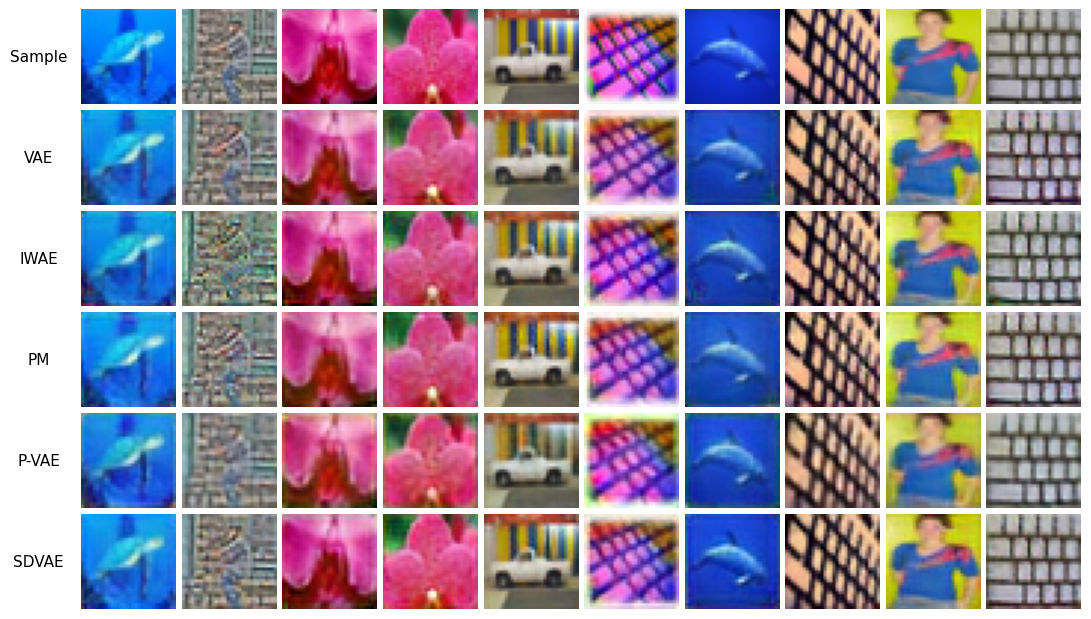

In [44]:
# ==========================================
# 绘图：行 = Sample + 各方法，列 = 挑中的图
# ==========================================

def _to_disp(t):
    return ((t + 1) / 2).clamp(0, 1)


def _draw_cell(ax, img_chw):
    img = img_chw.permute(1, 2, 0).numpy()
    if img.shape[-1] == 1:
        ax.imshow(img[..., 0], cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)


def build_rows(idx_list):
    """返回 [(行标签, [C,H,W] 图 batch), ...]，第一行是原图"""
    x = torch.stack([test_dataset[i] for i in idx_list]).to(device)
    rows = [("Sample", _to_disp(x).cpu())]
    for name, res in RESOLVED.items():
        model, bc = load_model(res)
        torch.manual_seed(SEED)
        rec = recon_batch(res, model, bc, x)
        rows.append((name, _to_disp(rec).detach().cpu()))
        del model, bc
        torch.cuda.empty_cache()
    return rows


CELL_IN = 1.0      # 每格边长(inch)
LABEL_IN = 0.85    # 左侧行标签留宽(inch)


def render(idx_list, out_stem):
    rows = build_rows(idx_list)
    nr, nc = len(rows), len(idx_list)
    # 按绝对 inch 布局：每格严格正方形，行/列间距才会一致（imshow 是等比的，
    # 格子非方时多余空间变成行内留白，看起来就是行距 > 列距）
    W, H = LABEL_IN + nc * CELL_IN, nr * CELL_IN
    fig, axes = plt.subplots(nr, nc, figsize=(W, H))
    axes = np.array(axes).reshape(nr, nc)
    plt.subplots_adjust(left=LABEL_IN / W, right=1.0, top=1.0, bottom=0.0, wspace=0.06, hspace=0.06)
    for r, (label, batch) in enumerate(rows):
        for c in range(nc):
            _draw_cell(axes[r, c], batch[c])
    # 行标签用 fig.text 而非 set_ylabel：set_ylabel 只能贴着 axes 右对齐，
    # 各标签长短不一（Sample / VAE）左端就参差不齐。这里按图坐标放到
    # 左侧留白带 [0, LABEL_IN/W] 的正中，纵向对齐该行 axes 的中心。
    x_label = (LABEL_IN / 2) / W
    for r, (label, _) in enumerate(rows):
        bb = axes[r, 0].get_position()
        fig.text(x_label, bb.y0 + bb.height / 2, label,
                 ha="center", va="center", fontsize=11)
    for ext, dpi in [("pdf", 300), ("png", 200)]:
        path = f"{OUT_DIR}/{out_stem}.{ext}"
        plt.savefig(path, bbox_inches="tight", dpi=dpi)
        print(f"已保存: {path}")
    plt.show()
    return rows


_stem = f"REC_medvae_{TARGET_DATASET}"
print("=== Top-K：SDVAE 优势最大的图 ===")
_ = render(top_idx, f"{_stem}_top{NUM_COLS}")

=== 随机挑图（对照） ===
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar100_random10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar100_random10.png


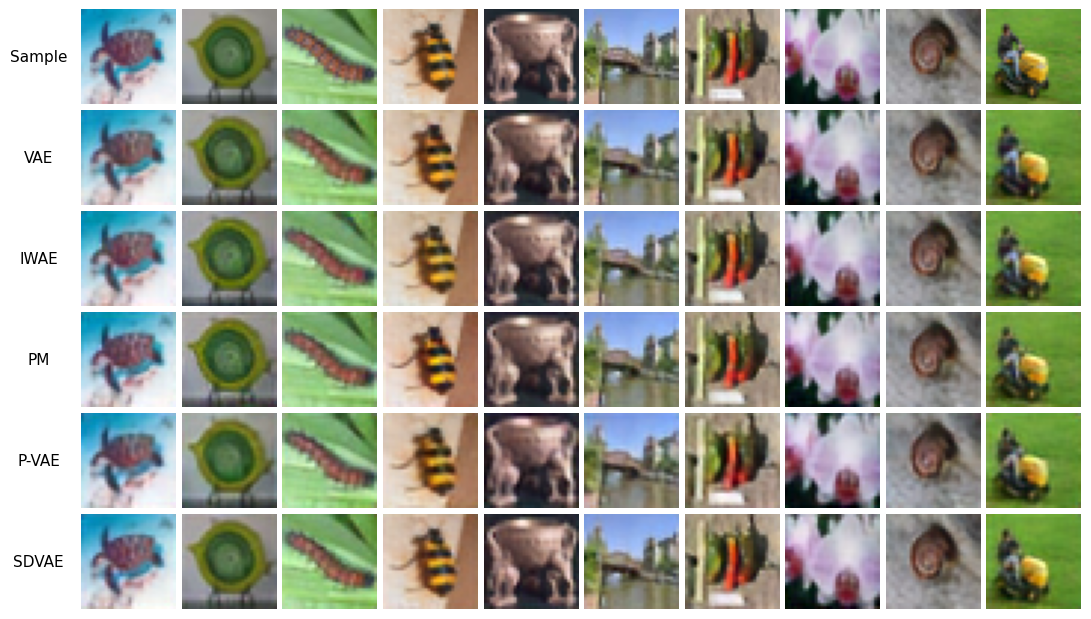

In [45]:
# ==========================================
# 对照版：随机挑图（证明不是只有精选图才好看；老师若嫌 Top-K 太挑，用这版）
# ==========================================
print("=== 随机挑图（对照） ===")
_ = render(rand_idx, f"{_stem}_random{NUM_COLS}")

In [46]:
# ==========================================
# 存盘：逐图 MSE + 选中索引（便于复查/复现，不用重跑）
# ==========================================

def save_meta(pim, resolved, ds, top, rand, wr, stem):
    meta = {
        "dataset": ds,
        "include_ncp": INCLUDE_NCP,
        "seed": SEED,
        "num_eval_images": int(len(next(iter(pim.values())))),
        "methods": {n: {"tag": r["tag"], "ckpt": r["path"]} for n, r in resolved.items()},
        "mse_mean_x1e3": {n: float(v.mean() * 1e3) for n, v in pim.items()},
        "main_table_mse_x1e3": {k: list(v) for k, v in MAIN_TABLE_MSE[ds].items()},
        "sdvae_win_rate": wr,
        "top_idx": top,
        "rand_idx": rand,
        "per_image_mse_x1e3": {n: (v * 1e3).round(4).tolist() for n, v in pim.items()},
    }
    path = f"{OUT_DIR}/{stem}_meta.json"
    with open(path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    print(f"已保存: {path}")


save_meta(per_image_mse, RESOLVED, TARGET_DATASET, top_idx, rand_idx, win_rate, _stem)
print(chr(10) + f"把 {OUT_DIR}/ 下的 pdf 拉回本地放进论文即可。")


已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar100_meta.json

把 /home/yzm/ipy/recfig_out/ 下的 pdf 拉回本地放进论文即可。


## Part C：跑全部五个数据集

Part B 是 cifar100 的单数据集走查（也是调试入口）。这里把同一套函数套到全部数据集上，
一次出齐 mnist / fashion-mnist / cifar10 / cifar100 / tiny-image-net 的图。

**骨干和方法代码通道无关，只有 `Config` 随数据集变**（见 CLAUDE.md），所以切完 config
就能直接复用 Part A/B 的全部函数，无需为每个数据集抄一份。

流程：**先 `precheck()` 纯 glob 扫一遍全部数据集的权重**（不加载模型、几秒钟），
把 tag 问题一次暴露干净，再跑耗时的逐图 MSE —— 免得跑到第三个数据集才 assert 崩掉。

⚠️ 本段会反复覆盖 `TARGET_DATASET` / `config` / `test_dataset` / `RESOLVED` /
`per_image_mse` 等全局量。每个数据集的图和 meta 跑完即落盘到 `OUT_DIR`，不会丢；
但**跑完想再单独出某个数据集的图，从 Part C 改 `DATASETS_TO_RUN` 重跑即可**。

In [47]:
# ==========================================
# 预检：只 glob 权重、不加载模型，把全部数据集的 tag 问题一次列清楚
# ==========================================

# Part B 已跑完 cifar100；想连它一起重跑就改成 list(DATASET_CFG)
DATASETS_TO_RUN = [d for d in DATASET_CFG if d != "cifar100"]


def precheck(datasets, include_ncp=INCLUDE_NCP):
    """返回 {ds: {method: tag or None}}，并打印可用性矩阵。

    只做 glob，不碰 GPU/数据集，所以几秒钟就能跑完；tag 对不上时
    直接把该数据集服务器上的真实 run/tag 打出来，省一轮往返。
    """
    names = [s["name"] for s in build_specs(datasets[0], include_ncp)]
    rows = {}
    for ds in datasets:
        r = {}
        for spec in build_specs(ds, include_ncp):
            if spec["kind"] == "ncp":
                bc = glob.glob(f"{_run_glob('ncp', ds)}/ncp/bc_logits.pth")
                r[spec["name"]] = "ncp" if (bc and os.path.exists(NCP_BASE_CKPT[ds])) else None
            else:
                _, tag = find_ckpt(spec["family"], ds, spec["tags"])
                r[spec["name"]] = tag
        rows[ds] = r

    w = 28
    print(f"{'数据集':<18}" + "".join(f"{n:<{w}}" for n in names))
    print("-" * (18 + w * len(names)))
    for ds, r in rows.items():
        print(f"{ds:<18}" + "".join(f"{(r[n] or '[!] 缺'):<{w}}" for n in names))
    print("-" * (18 + w * len(names)))

    bad = {ds: [n for n in names if not r[n]] for ds, r in rows.items()}
    bad = {ds: v for ds, v in bad.items() if v}
    if bad:
        for ds, v in bad.items():
            print(f"[!] {ds} 缺: {v}")
        print(chr(10) + "以下是缺权重数据集在服务器上的真实 run/tag，照它改 build_specs / PVAE_TAG：")
        for ds in bad:
            print()
            list_server_runs(ds)
    else:
        print(f"[OK] {len(datasets)} 个数据集 x {len(names)} 方法，权重全部就位。")
    return rows


_pre = precheck(DATASETS_TO_RUN)


数据集               VAE                         IWAE                        PM                          P-VAE                       SDVAE                       
--------------------------------------------------------------------------------------------------------------------------------------------------------------
mnist             vae_kl_1e-05                iwae_kl_1e-05               pm                          pvae_klw1e-08_pi0           dq_1e-05_klt_1e-08          
fashion-mnist     vae_kl_1e-05                iwae_kl_1e-05               pm                          pvae_klw1e-08_pi2           dq_1e-05_klt_1e-08          
cifar10           vae_kl_1e-05                iwae_kl_1e-05               pm                          pvae_klw1e-10_pi2           dq_1e-05_klt_1e-08          
tiny-image-net    vae_kl_1e-05                iwae_kl_1e-05               pm                          pvae_klw1e-10_pi2           dq_1e-05_klt_1e-08          
----------------------------------------------

In [48]:
# ==========================================
# 单数据集完整流程（复用 Part A/B 的全部函数）
# ==========================================

def switch_dataset(ds):
    """把数据集相关的全局量切到 ds：config / latent_resolution / test_dataset / test_loader"""
    global TARGET_DATASET, latent_resolution, test_dataset, test_loader
    assert ds in DATASET_CFG, f"未知数据集: {ds}"
    dc = DATASET_CFG[ds]
    TARGET_DATASET = ds
    config.DATASET_NAME = ds
    config.DATASET_DIR = dc["dir"]
    config.TRAIN_DATASET_DIR = os.path.join(dc["dir"], "train")
    config.TEST_DATASET_DIR = os.path.join(dc["dir"], "test")
    config.IMAGE_KEY = dc["key"]
    config.IMG_SIZE = dc["size"]
    config.IMG_CHANNELS = dc["ch"]
    # make_ddconfig 每次调用都现读 config，会自动跟着变；
    # 但 latent_resolution 是 cell 16 一次算好的常量，必须在这里跟着改，否则
    # 32x32 的 16 会带到 28x28 上，NCP 分类器维度对不上。
    latent_resolution = config.IMG_SIZE // 2
    test_dataset = HFImageDataset(split="test", augment=False)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, drop_last=False, pin_memory=True,
    )
    print(f"已切到 {ds}: {config.IMG_SIZE}x{config.IMG_SIZE}x{config.IMG_CHANNELS}，"
          f"测试集 {len(test_dataset)} 张，潜在 {latent_resolution}x{latent_resolution}")


def run_dataset(ds):
    """切数据集 -> 逐图 MSE -> 核对主表 -> 挑图 -> 出图 -> 存盘。缺权重则跳过返回 None。"""
    global RESOLVED, per_image_mse, N_EVAL, top_idx, rand_idx, win_rate, _stem
    print(chr(10) + "=" * 86)
    print(f"###  {ds}")
    print("=" * 86)
    switch_dataset(ds)

    RESOLVED, miss = resolve_ckpts(build_specs(ds, INCLUDE_NCP), ds)
    if miss:
        print(f"[跳过] {ds}: 缺 {miss}（不画半套图，先把 tag 修对）")
        return None

    per_image_mse = compute_per_image_mse(RESOLVED, test_loader, MAX_EVAL_IMAGES)
    N_EVAL = len(next(iter(per_image_mse.values())))
    print(chr(10) + f"逐图 MSE 完成：{N_EVAL} 张 x {len(per_image_mse)} 方法" + chr(10))

    check_main_table(per_image_mse, ds)
    print()
    top_idx, rand_idx, win_rate = pick_images(per_image_mse, NUM_COLS, TOP_POOL)

    _stem = f"REC_medvae_{ds}"
    print(chr(10) + f"=== {ds}: Top-{NUM_COLS}（SDVAE 优势最大）===")
    render(top_idx, f"{_stem}_top{NUM_COLS}")
    print(f"=== {ds}: 随机 {NUM_COLS} 张（对照）===")
    render(rand_idx, f"{_stem}_random{NUM_COLS}")
    save_meta(per_image_mse, RESOLVED, ds, top_idx, rand_idx, win_rate, _stem)

    return {
        "dataset": ds,
        "n_eval": N_EVAL,
        "win_rate": win_rate,
        "mse_x1e3": {n: float(v.mean() * 1e3) for n, v in per_image_mse.items()},
        "order": " < ".join(sorted(per_image_mse, key=lambda n: per_image_mse[n].mean())),
        "tags": {n: r["tag"] for n, r in RESOLVED.items()},
    }



###  mnist
[test] 数据集路径: /home/yzm/data_mnist/test
[test] 数据集大小: 10000
[test] 数据集列: ['image', 'label']
已切到 mnist: 28x28x1，测试集 10000 张，潜在 14x14
方法      状态      tag                         权重
--------------------------------------------------------------------------------------------------------------
VAE     OK      vae_kl_1e-05                /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth
IWAE    OK      iwae_kl_1e-05               /home/yzm/ipy/checkpoints/medvae-re-mnist-06-26_05-42/iwae_kl_1e-05/medvae_iwae_kl_1e-05_epoch10.pth
PM      OK      pm                          /home/yzm/ipy/checkpoints/medvae-re-pm-mnist-07-04_22-57/pm/medvae_pm_epoch10.pth
P-VAE   OK      pvae_klw1e-08_pi0           /home/yzm/ipy/checkpoints/medvae-re-pvae-mnist-07-05_18-43/pvae_klw1e-08_pi0/medvae_pvae_klw1e-08_pi0_epoch10.pth
                                            [备选] 首选 pvae_final_klw1e-08_pi0 不存在
SDVAE   OK      dq_1e-05_klt_1e-08          /h

SDVAE : 100%|██████████| 157/157 [00:02<00:00, 53.66it/s]



逐图 MSE 完成：10000 张 x 5 方法

mnist  MSE (x10^-3)

方法             本次             主表       差      偏离   判定
--------------------------------------------------------------
VAE          0.67      0.68±0.03   -0.01    0.5σ   一致
IWAE         0.76      0.71±0.04   +0.05    1.1σ   一致
PM           0.63      0.68±0.04   -0.05    1.3σ   一致
P-VAE        1.46      1.46±0.12   -0.00    0.0σ   一致
SDVAE        0.50      0.50±0.01   -0.00    0.0σ   一致
--------------------------------------------------------------
注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；
    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。

本次 MSE 排序: SDVAE < PM < VAE < IWAE < P-VAE
主表 MSE 排序: SDVAE < VAE < PM < IWAE < NCP < P-VAE   (含 NCP，本次未必画)

SDVAE 逐图全胜（优于其他全部方法）比例: 81.9%  (8187/10000)
挑图准则: gap_covered

选中 10 张; 随机 10 张索引: [859, 7733, 891, 6541, 4386, 4327, 6972, 941, 2014, 8582]

选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：
idx          VAE     IWAE       PM    P-VAE    SDVAE               崩
----------------------------------------------

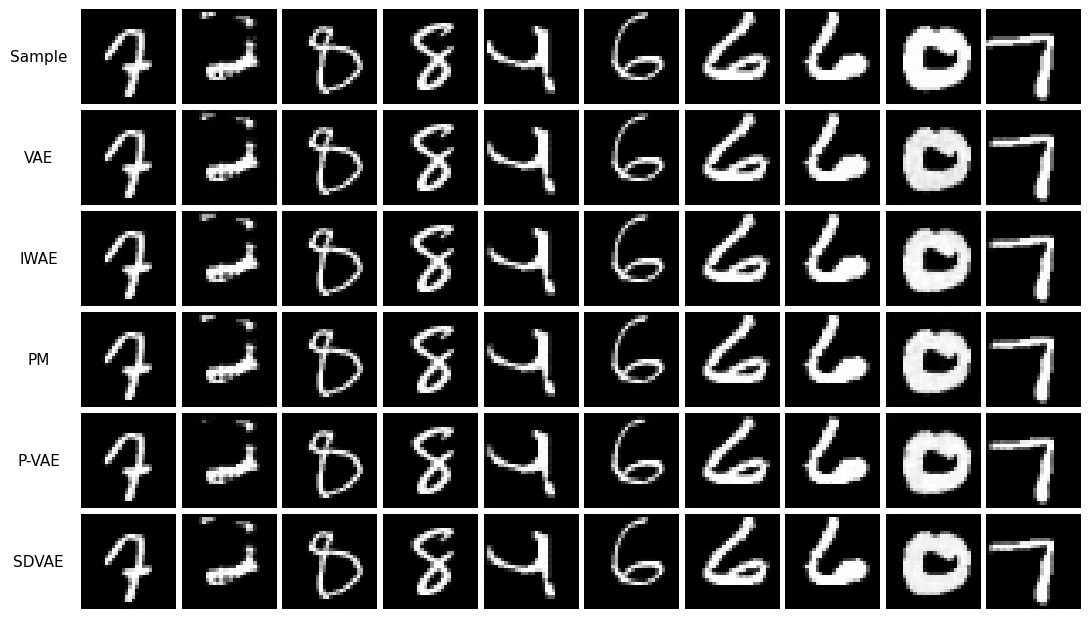

=== mnist: 随机 10 张（对照）===
已保存: /home/yzm/ipy/recfig_out/REC_medvae_mnist_random10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_mnist_random10.png


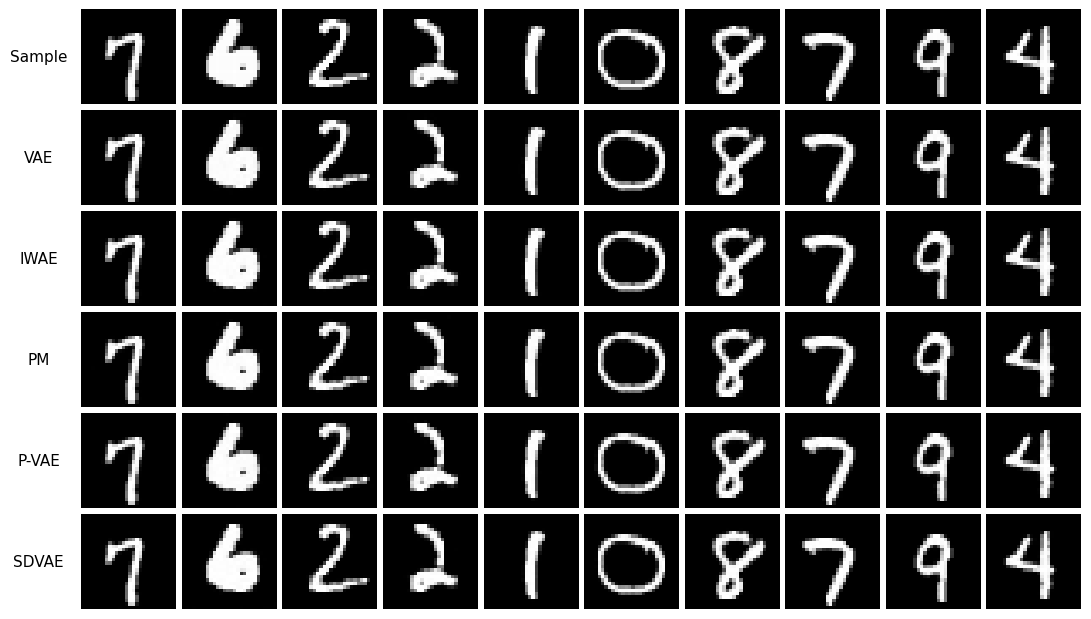

已保存: /home/yzm/ipy/recfig_out/REC_medvae_mnist_meta.json

###  fashion-mnist
[test] 数据集路径: /home/yzm/data_fashion_mnist/test
[test] 数据集大小: 10000
[test] 数据集列: ['image', 'label']
已切到 fashion-mnist: 28x28x1，测试集 10000 张，潜在 14x14
方法      状态      tag                         权重
--------------------------------------------------------------------------------------------------------------
VAE     OK      vae_kl_1e-05                /home/yzm/ipy/checkpoints/medvae-re-fashion-mnist-06-24_00-50/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth
IWAE    OK      iwae_kl_1e-05               /home/yzm/ipy/checkpoints/medvae-re-fashion-mnist-06-24_00-50/iwae_kl_1e-05/medvae_iwae_kl_1e-05_epoch10.pth
PM      OK      pm                          /home/yzm/ipy/checkpoints/medvae-re-pm-fashion-mnist-07-05_00-22/pm/medvae_pm_epoch10.pth
P-VAE   OK      pvae_klw1e-08_pi2           /home/yzm/ipy/checkpoints/medvae-re-pvae-fashion-mnist-07-05_20-11/pvae_klw1e-08_pi2/medvae_pvae_klw1e-08_pi2_epoch10.pth
             

SDVAE : 100%|██████████| 157/157 [00:02<00:00, 53.62it/s]



逐图 MSE 完成：10000 张 x 5 方法

fashion-mnist  MSE (x10^-3)

方法             本次             主表       差      偏离   判定
--------------------------------------------------------------
VAE          3.46      3.40±0.40   +0.06    0.1σ   一致
IWAE         2.02      3.61±0.28   -1.59    5.7σ   [!] 对不上
PM           1.89      3.03±0.95   -1.14    1.2σ   一致
P-VAE        3.45      3.45±0.31   -0.00    0.0σ   一致
SDVAE        3.29      1.92±0.86   +1.37    1.6σ   一致
--------------------------------------------------------------
注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；
    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。

本次 MSE 排序: PM < IWAE < SDVAE < P-VAE < VAE
主表 MSE 排序: SDVAE < PM < VAE < P-VAE < IWAE < NCP   (含 NCP，本次未必画)

SDVAE 逐图全胜（优于其他全部方法）比例: 3.5%  (349/10000)
挑图准则: gap_covered

选中 10 张; 随机 10 张索引: [859, 7733, 891, 6541, 4386, 4327, 6972, 941, 2014, 8582]

选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：
idx          VAE     IWAE       PM    P-VAE    SDVAE               崩
-----------------------------------

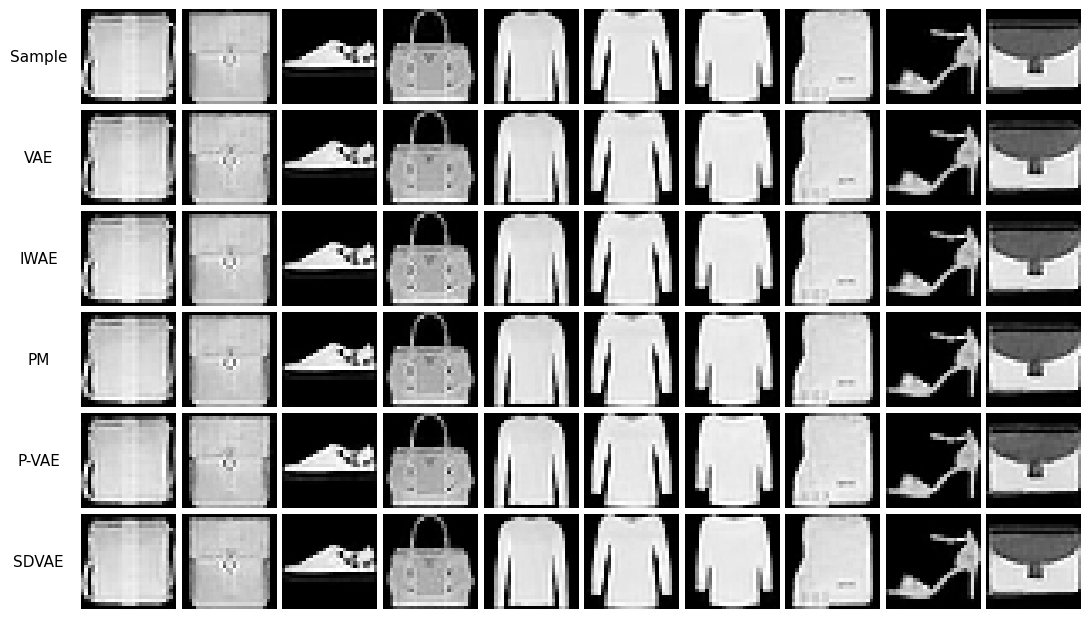

=== fashion-mnist: 随机 10 张（对照）===
已保存: /home/yzm/ipy/recfig_out/REC_medvae_fashion-mnist_random10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_fashion-mnist_random10.png


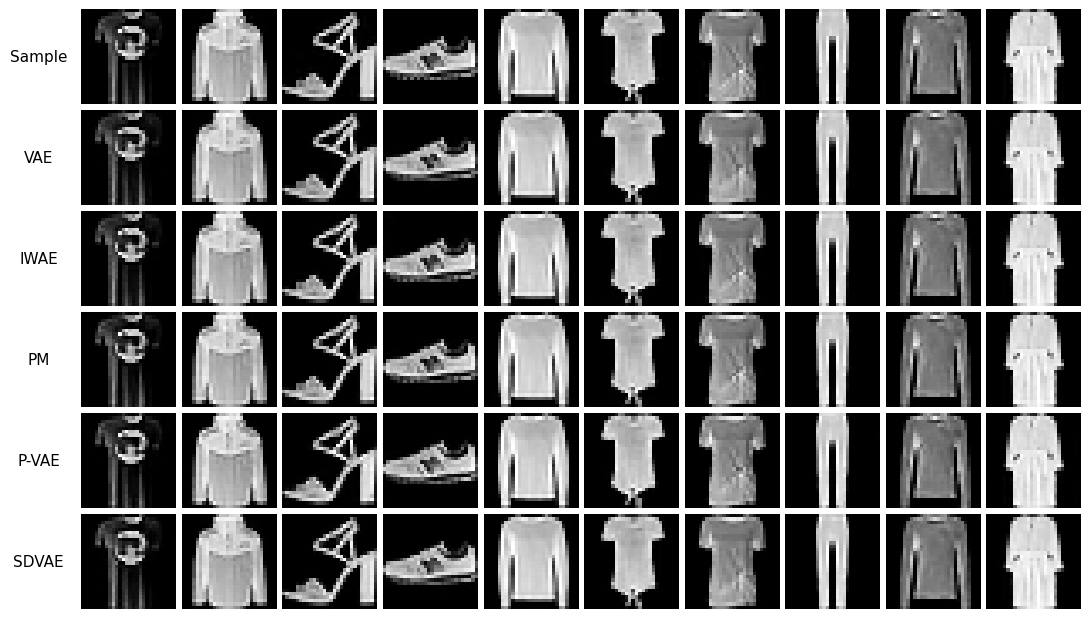

已保存: /home/yzm/ipy/recfig_out/REC_medvae_fashion-mnist_meta.json

###  cifar10
[test] 数据集路径: /home/yzm/data_cifar10/test
[test] 数据集大小: 10000
[test] 数据集列: ['img', 'label']
已切到 cifar10: 32x32x3，测试集 10000 张，潜在 16x16
方法      状态      tag                         权重
--------------------------------------------------------------------------------------------------------------
VAE     OK      vae_kl_1e-05                /home/yzm/ipy/checkpoints/medvae-re-cifar10-06-22_14-53/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth
IWAE    OK      iwae_kl_1e-05               /home/yzm/ipy/checkpoints/medvae-re-cifar10-06-22_14-53/iwae_kl_1e-05/medvae_iwae_kl_1e-05_epoch10.pth
PM      OK      pm                          /home/yzm/ipy/checkpoints/medvae-re-pm-cifar10-07-05_01-39/pm/medvae_pm_epoch10.pth
P-VAE   OK      pvae_klw1e-10_pi2           /home/yzm/ipy/checkpoints/medvae-re-pvae-cifar10-07-05_18-43/pvae_klw1e-10_pi2/medvae_pvae_klw1e-10_pi2_epoch10.pth
                                            [备选] 

SDVAE : 100%|██████████| 157/157 [00:03<00:00, 50.46it/s]



逐图 MSE 完成：10000 张 x 5 方法

cifar10  MSE (x10^-3)

方法             本次             主表       差      偏离   判定
--------------------------------------------------------------
VAE          3.25      3.45±0.12   -0.20    1.6σ   一致
IWAE         3.93      3.70±0.19   +0.23    1.2σ   一致
PM           3.30      3.36±0.13   -0.06    0.5σ   一致
P-VAE        4.57      4.58±0.25   -0.01    0.0σ   一致
SDVAE        2.79      2.88±0.08   -0.09    1.1σ   一致
--------------------------------------------------------------
注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；
    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。

本次 MSE 排序: SDVAE < VAE < PM < IWAE < P-VAE
主表 MSE 排序: SDVAE < NCP < PM < VAE < IWAE < P-VAE   (含 NCP，本次未必画)

SDVAE 逐图全胜（优于其他全部方法）比例: 85.2%  (8520/10000)
挑图准则: gap_covered

选中 10 张; 随机 10 张索引: [859, 7733, 891, 6541, 4386, 4327, 6972, 941, 2014, 8582]

选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：
idx          VAE     IWAE       PM    P-VAE    SDVAE               崩
--------------------------------------------

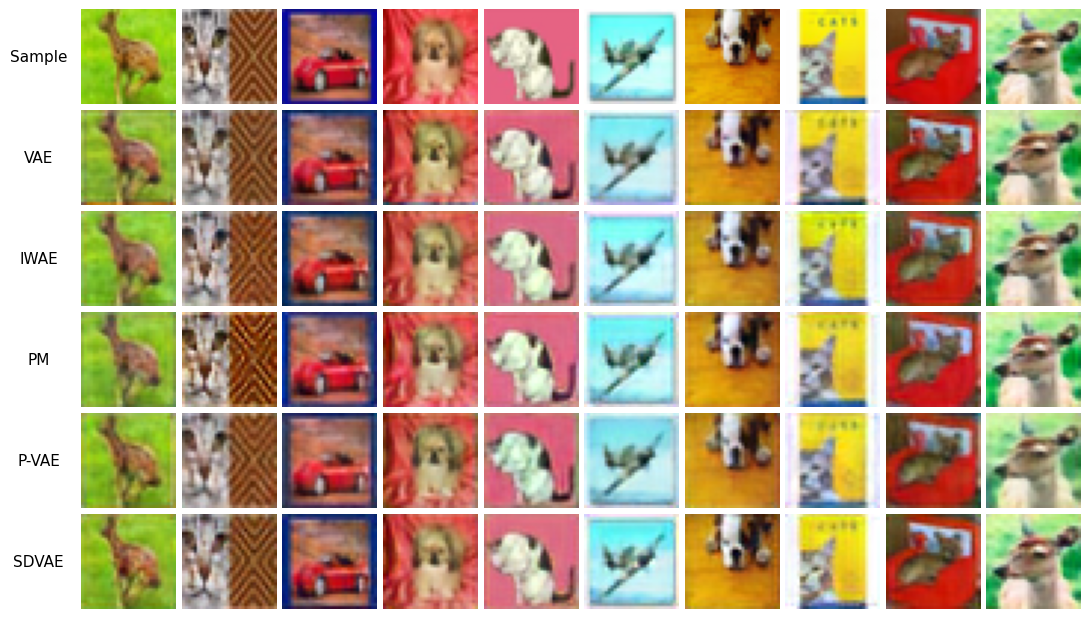

=== cifar10: 随机 10 张（对照）===
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar10_random10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar10_random10.png


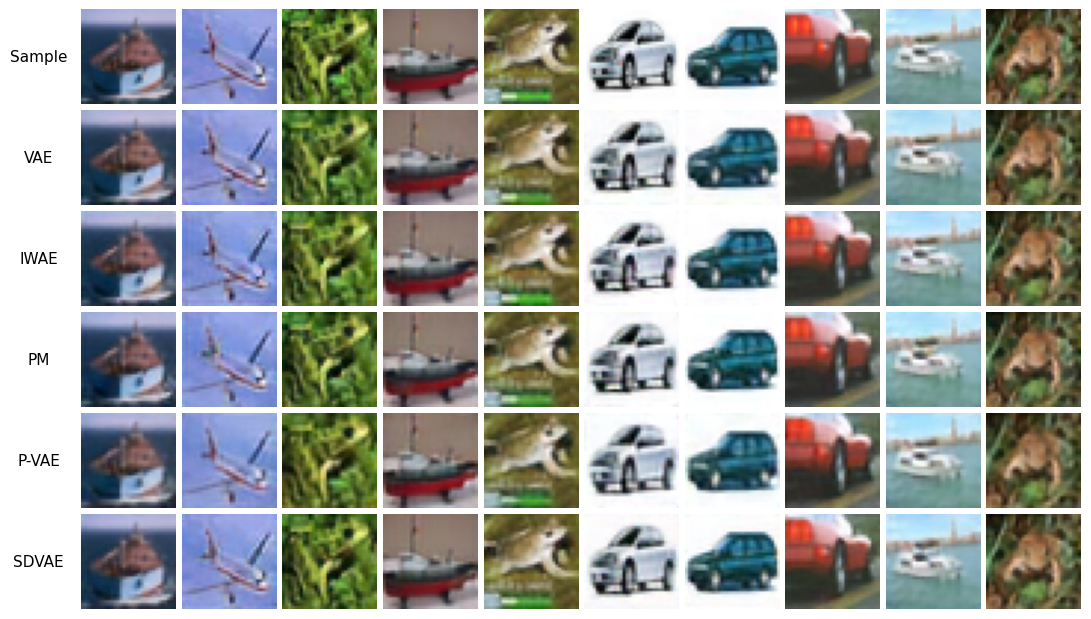

已保存: /home/yzm/ipy/recfig_out/REC_medvae_cifar10_meta.json

###  tiny-image-net
[test] 数据集路径: /home/yzm/data_tiny_image_net/test
[test] 数据集大小: 10000
[test] 数据集列: ['image', 'label']
已切到 tiny-image-net: 64x64x3，测试集 10000 张，潜在 32x32
方法      状态      tag                         权重
--------------------------------------------------------------------------------------------------------------
VAE     OK      vae_kl_1e-05                /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/medvae_vae_kl_1e-05_epoch10.pth
IWAE    OK      iwae_kl_1e-05               /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/iwae_kl_1e-05/medvae_iwae_kl_1e-05_epoch10.pth
PM      OK      pm                          /home/yzm/ipy/checkpoints/medvae-re-pm-tiny-image-net-06-27_17-02/pm/medvae_pm_epoch10.pth
P-VAE   OK      pvae_klw1e-10_pi2           /home/yzm/ipy/checkpoints/medvae-re-pvae-tiny-image-net-07-05_18-43/pvae_klw1e-10_pi2/medvae_pvae_klw1e-10_pi2_epoch10.pth
    

SDVAE : 100%|██████████| 157/157 [00:09<00:00, 16.97it/s]



逐图 MSE 完成：10000 张 x 5 方法

tiny-image-net  MSE (x10^-3)

方法             本次             主表       差      偏离   判定
--------------------------------------------------------------
VAE         10.15     10.47±0.55   -0.32    0.6σ   一致
IWAE        11.30     10.65±0.64   +0.65    1.0σ   一致
PM           9.45     10.14±0.56   -0.69    1.2σ   一致
P-VAE        9.91      9.91±0.54   +0.00    0.0σ   一致
SDVAE        8.31      8.64±0.68   -0.33    0.5σ   一致
--------------------------------------------------------------
注：主表是 5 次 run 的均值±std，本次是其中单个 checkpoint，落在 2σ 内即正常；
    超出才说明 tag 选错或权重不是主表那批，回 Part A 查。

本次 MSE 排序: SDVAE < PM < P-VAE < VAE < IWAE
主表 MSE 排序: SDVAE < NCP < P-VAE < PM < VAE < IWAE   (含 NCP，本次未必画)

SDVAE 逐图全胜（优于其他全部方法）比例: 91.5%  (9153/10000)
挑图准则: gap_covered

选中 10 张; 随机 10 张索引: [859, 7733, 891, 6541, 4386, 4327, 6972, 941, 2014, 8582]

选中图的 MSE (x10^-3)  [崩=该列最差方法及其相对 SDVAE 倍数]：
idx          VAE     IWAE       PM    P-VAE    SDVAE               崩
-------------------------------------

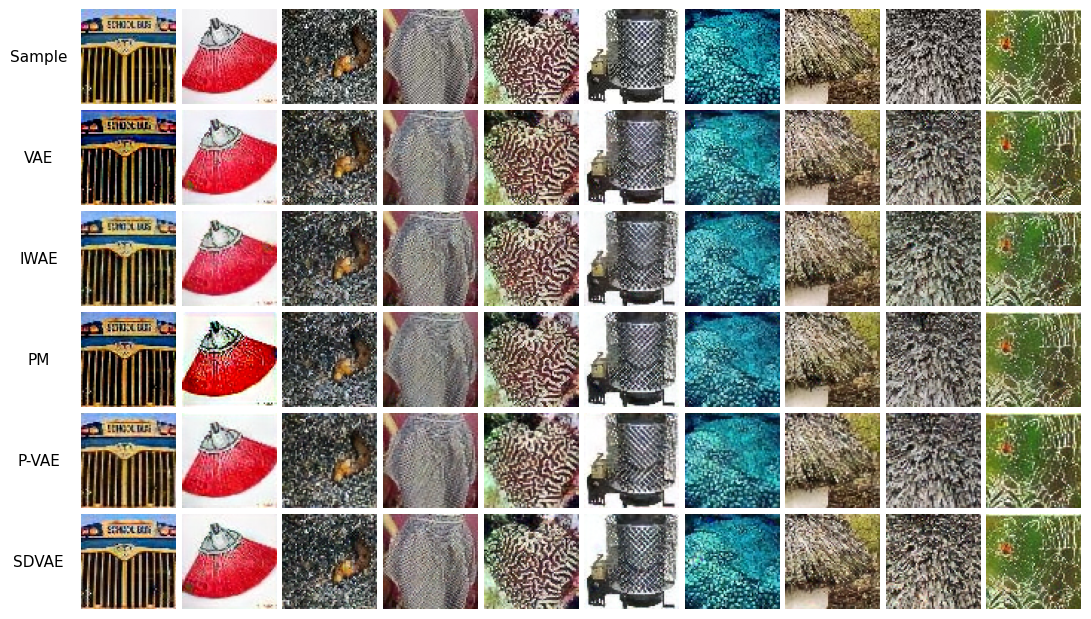

=== tiny-image-net: 随机 10 张（对照）===
已保存: /home/yzm/ipy/recfig_out/REC_medvae_tiny-image-net_random10.pdf
已保存: /home/yzm/ipy/recfig_out/REC_medvae_tiny-image-net_random10.png


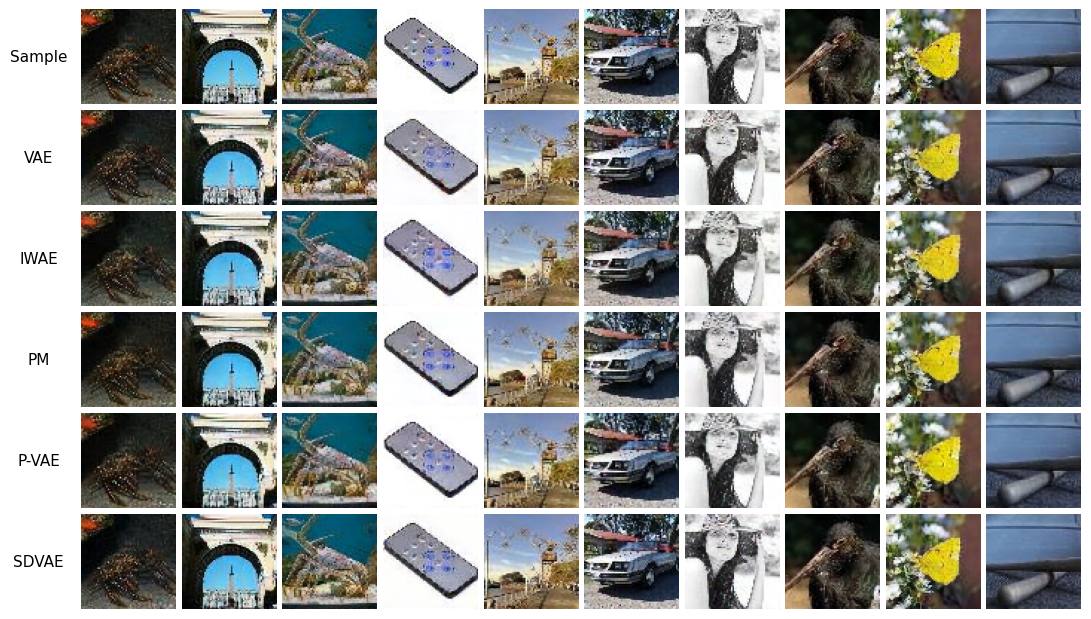

已保存: /home/yzm/ipy/recfig_out/REC_medvae_tiny-image-net_meta.json


###  汇总


In [49]:
# ==========================================
# 跑全部数据集（耗时大头：每个数据集 5 个方法各过一遍测试集）
# ==========================================
RESULTS = []
for _ds in DATASETS_TO_RUN:
    _r = run_dataset(_ds)
    if _r:
        RESULTS.append(_r)

print(chr(10) * 2 + "=" * 86)
print("###  汇总")
print("=" * 86)


In [ ]:
# ==========================================
# 汇总表：各数据集的 SDVAE 全胜率 / 排序 / 与主表是否同序
# ==========================================
print(f"{'数据集':<18}{'全胜率':>8}{'本次 MSE 排序':<42}主表同序")
print("-" * 96)
for r in RESULTS:
    ref = MAIN_TABLE_MSE[r["dataset"]]
    ref_order = [n for n in sorted(ref, key=lambda n: ref[n][0]) if n in r["mse_x1e3"]]
    same = "是" if ref_order == r["order"].split(" < ") else "否"
    print(f"{r['dataset']:<18}{r['win_rate']:>7.1%} {r['order']:<42}{same}")
print("-" * 96)
print("注：「主表同序」比的是本次单 checkpoint 与主表 5-run 均值的方法排序；")
print("    「否」不一定是错——主表相邻两格常在 1 个 std 内（如 cifar100 VAE/IWAE），")
print("    单次采样换序很正常。SDVAE 是否稳居第一才是要看的。")

print(chr(10) + f"图已全部落在 {OUT_DIR}/：")
for r in RESULTS:
    print(f"  REC_medvae_{r['dataset']}_top{NUM_COLS}.pdf   /  _random{NUM_COLS}.pdf")
_skipped = [d for d in DATASETS_TO_RUN if d not in [r["dataset"] for r in RESULTS]]
if _skipped:
    print(chr(10) + f"[!] 跳过（缺权重）: {_skipped}")


数据集                    全胜率本次 MSE 排序                                 主表同序
------------------------------------------------------------------------------------------------
mnist               81.9% SDVAE < PM < VAE < IWAE < P-VAE           否
fashion-mnist        3.5% PM < IWAE < SDVAE < P-VAE < VAE           否
cifar10             85.2% SDVAE < VAE < PM < IWAE < P-VAE           否
tiny-image-net      91.5% SDVAE < PM < P-VAE < VAE < IWAE           否
------------------------------------------------------------------------------------------------
注：「主表同序」比的是本次单 checkpoint 与主表 5-run 均值的方法排序；
    「否」不一定是错——主表相邻两格常在 1 个 std 内（如 cifar100 VAE/IWAE），
    单次采样换序很正常。SDVAE 是否稳居第一才是要看的。

图已全部落在 /home/yzm/ipy/recfig_out/：
  REC_medvae_mnist_top10.pdf   /  _random10.pdf
  REC_medvae_fashion-mnist_top10.pdf   /  _random10.pdf
  REC_medvae_cifar10_top10.pdf   /  _random10.pdf
  REC_medvae_tiny-image-net_top10.pdf   /  _random10.pdf


: 

## eof